In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os 
from statsmodels.stats.proportion import proportions_ztest
os.chdir('/Users/lior/DS6021/DS6021_F26/data')

peng = pd.read_csv('penguins.csv').dropna(subset=['body_mass_g'])

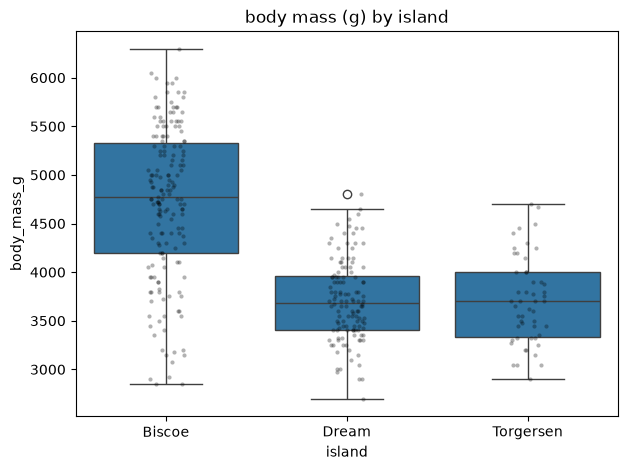

In [15]:
#Body Mass of Penguins
plt.figure(figsize=(7,5))
island_order = ['Biscoe', 'Dream', 'Torgersen']

sns.boxplot(data=peng, x='island', y='body_mass_g', order=island_order)
sns.stripplot(data=peng, x='island', y='body_mass_g', order=island_order,
              color='black', alpha=0.3, size=3) 

plt.title('body mass (g) by island')
plt.show()


This analysis show that Biscoe penguins are considerably heavier than the penguins on the other islands as shown by the fact that they have the highest median (4775.0g). The box plot shows that the biscoe penguin box plot sits a lot higher than the others and doesnt overlap at the interquartile ranges, while the Dream and Torgersen islands are very similar to eachother. 

In [17]:
#Q2: Are penguins on Biscoe island larger?

peng['is_large'] = peng['body_mass_g'] > peng['body_mass_g'].median()
ct = pd.crosstab(peng['island'], peng['is_large'])
print(ct)
n_biscoe = (peng['island'] == 'Biscoe').sum()
n_other  = (peng['island'] != 'Biscoe').sum()
big_biscoe = ((peng['island'] == 'Biscoe') & (peng['is_large'])).sum()
big_other  = ((peng['island'] != 'Biscoe')& (peng['is_large'])).sum()

count = [big_biscoe, big_other]
nobs  = [n_biscoe, n_other]
stat, pval = proportions_ztest(count, nobs, alternative='larger')
print(f"biscoe: {big_biscoe}/{n_biscoe} = {big_biscoe/n_biscoe:.3f}")
print(f"other:  {big_other}/{n_other} = {big_other/n_other:.3f}")
print(f"Z = {stat:.4f}, p-value = {pval:.6f}")

is_large   False  True 
island                 
Biscoe        36    131
Dream        100     24
Torgersen     40     11
biscoe: 131/167 = 0.784
other:  35/175 = 0.200
Z = 10.8097, p-value = 0.000000


After running a one sided two proportion z test with Biscoe vs the other islands, it showed that the Biscoe value (0.784)is greater than the other islands (0.200). This shows that the results are statistically significant. So by this test, the penguins on Biscoe island are a lot more liekly to be a lot bigger than the penguins everywhere else (78%>20%).

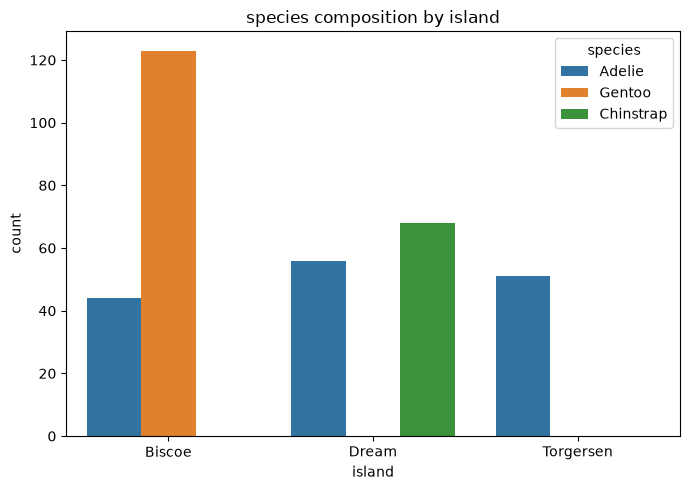

species    Adelie  Chinstrap  Gentoo
island                              
Biscoe         44          0     123
Dream          56         68       0
Torgersen      51          0       0


In [19]:
# Q3 Visualization

plt.figure(figsize=(7,5))
sns.countplot(data=peng, x='island', hue='species', order=['Biscoe','Dream','Torgersen'])
plt.title('species composition by island')
plt.tight_layout()
plt.show()
print(pd.crosstab(peng['island'], peng['species']))

After visualizing the data, it shows that penguins on Biscoe island are largely dominated by Gentoo penguins, and is the only island who houses these penguins out of the three. There are also a lot more penguins on Biscoe island than the other islands. So my original thought on the penguins on Biscoe island might be true, but statistically there are 167 penguins on Biscoe island vs 124 on Dream island and 51 on Torgersen. 

Biscoe Adelie: 9/44 = 0.205
Other Adelie:  24/107 = 0.224
Z = -0.2669, p-value = 0.605228


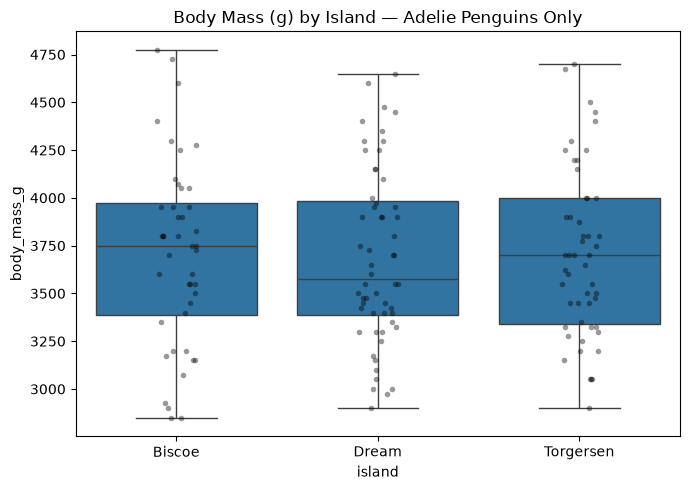

In [20]:
#Q4: Proportion of one penguin species
adelie = peng[peng['species'] == 'Adelie']

n_biscoe_a = (adelie['island'] == 'Biscoe').sum()
n_other_a  = (adelie['island'] != 'Biscoe').sum()
large_biscoe_a = ((adelie['island'] == 'Biscoe') & (adelie['is_large'])).sum()
large_other_a  = ((adelie['island'] != 'Biscoe') & (adelie['is_large'])).sum()

count_a = [large_biscoe_a, large_other_a]
nobs_a  = [n_biscoe_a, n_other_a]

stat_a, pval_a = proportions_ztest(count_a, nobs_a, alternative='larger')
print(f"Biscoe Adelie: {large_biscoe_a}/{n_biscoe_a} = {large_biscoe_a/n_biscoe_a:.3f}")
print(f"Other Adelie:  {large_other_a}/{n_other_a} = {large_other_a/n_other_a:.3f}")
print(f"Z = {stat_a:.4f}, p-value = {pval_a:.6f}")
plt.figure(figsize=(7,5))
sns.boxplot(data=adelie, x='island', y='body_mass_g', order=['Biscoe','Dream','Torgersen'])
sns.stripplot(data=adelie, x='island', y='body_mass_g', order=['Biscoe','Dream','Torgersen'],
              color='black', alpha=0.4, size=4)
plt.title('Body Mass (g) by Island — Adelie Penguins Only')
plt.tight_layout()
plt.show()



I chose Adelie since its the common species between all three islands. When were just comparing the same species, it seems all the island results are similar compared to the first box plot that we generated. 